Dataset Loading

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/amazon-prediction/amazon_delivery (1).csv")
df.head()


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


Data Inspection

In [2]:
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


DATA CLEANING

In [3]:
import pandas as pd
import numpy as np

# 1. Check missing values (before cleaning)
print("Missing values BEFORE cleaning:\n")
print(df.isnull().sum())
print("-" * 50)

# 2. Handle missing values
# Numeric: Agent_Rating → median
df['Agent_Rating'] = df['Agent_Rating'].fillna(df['Agent_Rating'].median())

# Categorical: Weather → mode
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

# 3. Remove duplicate rows
df = df.drop_duplicates()

# 4. Drop non-informative / leakage columns
df = df.drop(columns=['Order_ID', 'Category'])

# 5. Check missing values (after cleaning)
print("\nMissing values AFTER cleaning:\n")
print(df.isnull().sum())
print("-" * 50)

# 6. Final dataset info
df.info()


Missing values BEFORE cleaning:

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64
--------------------------------------------------

Missing values AFTER cleaning:

Agent_Age          0
Agent_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
dtype: int64
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  

Date & Time Feature Engineering

In [4]:
import pandas as pd
import numpy as np

# 1. Convert Order_Date safely
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# 2. Convert Order_Time & Pickup_Time safely (handle NaN / bad values)
df['Order_Time'] = pd.to_datetime(
    df['Order_Time'], format='%H:%M:%S', errors='coerce'
)

df['Pickup_Time'] = pd.to_datetime(
    df['Pickup_Time'], format='%H:%M:%S', errors='coerce'
)

# 3. Fill missing Pickup_Time with Order_Time (logical assumption)
df['Pickup_Time'] = df['Pickup_Time'].fillna(df['Order_Time'])

# 4. Extract time-based features
df['Order_Hour'] = df['Order_Time'].dt.hour
df['Order_Day'] = df['Order_Date'].dt.dayofweek  # 0=Monday

# 5. Pickup delay feature (minutes)
df['Pickup_Delay_Min'] = (
    df['Pickup_Time'] - df['Order_Time']
).dt.total_seconds() / 60

# 6. Handle negative / missing delays
df['Pickup_Delay_Min'] = df['Pickup_Delay_Min'].fillna(0)
df['Pickup_Delay_Min'] = df['Pickup_Delay_Min'].clip(lower=0)

# 7. Quick verification
df[['Order_Hour', 'Order_Day', 'Pickup_Delay_Min']].head()


,Order_Hour,Order_Day,Pickup_Delay_Min
0,11.0,5,15.0
1,19.0,4,5.0
2,8.0,5,15.0
3,18.0,1,10.0
4,13.0,5,15.0


Distance Feature Engineering

In [5]:
import numpy as np

# 1. Haversine distance function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in KM
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2)**2 + np.cos(np.radians(lat1)) * \
        np.cos(np.radians(lat2)) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# 2. Create Distance_km feature
df['Distance_km'] = haversine(
    df['Store_Latitude'], df['Store_Longitude'],
    df['Drop_Latitude'], df['Drop_Longitude']
)

# 3. Verify distance values
df[['Distance_km']].describe()


,Distance_km
count,43739.000000
mean,38.561752
std,534.564299
min,1.465067
25%,4.663432
50%,9.220450
75%,13.682379
max,19692.674606


Outlier Handling & Feature Finalization

In [6]:
import numpy as np

# 1. Cap extreme distance outliers (99th percentile)
upper_limit = df['Distance_km'].quantile(0.99)

df['Distance_km'] = df['Distance_km'].clip(upper=upper_limit)

# 2. Drop latitude & longitude columns (no longer needed)
df = df.drop(columns=[
    'Store_Latitude', 'Store_Longitude',
    'Drop_Latitude', 'Drop_Longitude'
])

# 3. Verify distance after clipping
df['Distance_km'].describe()


count    43739.000000
mean         9.781606
std          5.639125
min          1.465067
25%          4.663432
50%          9.220450
75%         13.682379
max         20.851863
Name: Distance_km, dtype: float64

EDA & LOGIC VALIDATION

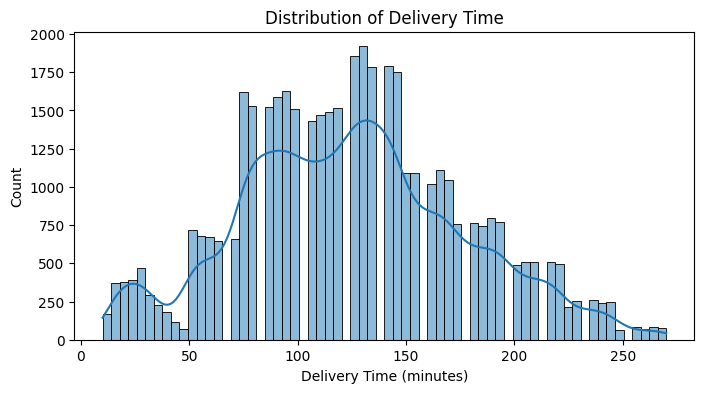

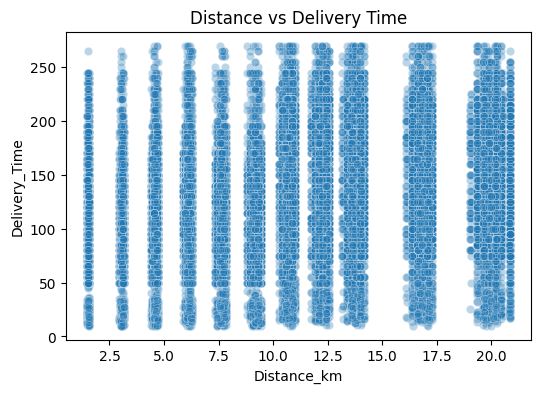

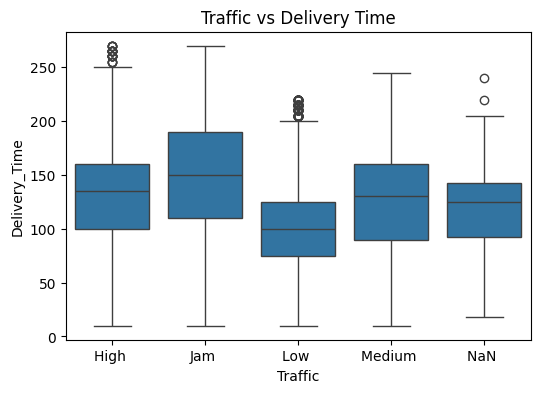

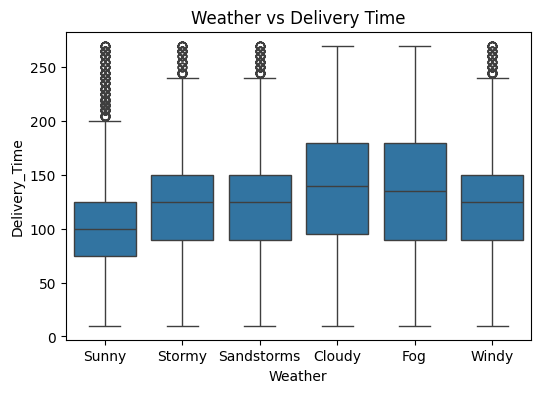

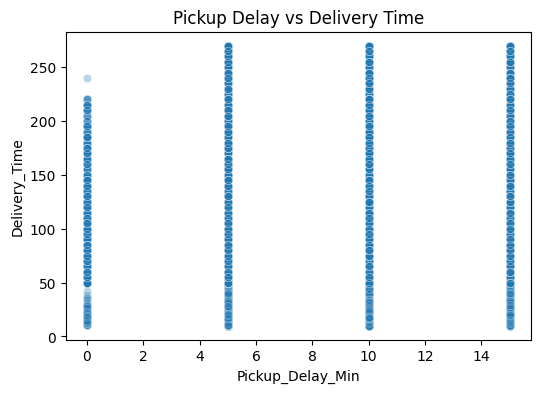

In [7]:


import seaborn as sns
import matplotlib.pyplot as plt

# 1. Delivery Time Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Delivery_Time'], kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.show()

# 2. Distance vs Delivery Time
plt.figure(figsize=(6,4))
sns.scatterplot(x='Distance_km', y='Delivery_Time', data=df, alpha=0.3)
plt.title("Distance vs Delivery Time")
plt.show()

# 3. Traffic impact
plt.figure(figsize=(6,4))
sns.boxplot(x='Traffic', y='Delivery_Time', data=df)
plt.title("Traffic vs Delivery Time")
plt.show()

# 4. Weather impact
plt.figure(figsize=(6,4))
sns.boxplot(x='Weather', y='Delivery_Time', data=df)
plt.title("Weather vs Delivery Time")
plt.show()

# 5. Pickup delay impact
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Pickup_Delay_Min', y='Delivery_Time',
    data=df, alpha=0.3
)
plt.title("Pickup Delay vs Delivery Time")
plt.show()


Feature grouping + train-test split

In [8]:
from sklearn.model_selection import train_test_split

# 1. Define numerical and categorical columns
num_cols = [
    'Agent_Age',
    'Agent_Rating',
    'Distance_km',
    'Order_Hour',
    'Order_Day',
    'Pickup_Delay_Min'
]

cat_cols = [
    'Traffic',
    'Weather',
    'Vehicle',
    'Area'
]

# 2. Define feature matrix X and target y
X = df[num_cols + cat_cols]
y = df['Delivery_Time']

# 3. Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 4. Quick verification
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

# 5. Preview training data
X_train.head()


X_train shape: (34991, 10)
X_test shape : (8748, 10)
y_train shape: (34991,)
y_test shape : (8748,)


,Agent_Age,Agent_Rating,Distance_km,Order_Hour,Order_Day,Pickup_Delay_Min,Traffic,Weather,Vehicle,Area
39398,26,4.7,12.073552,20.0,0,5.0,Jam,Sunny,scooter,Metropolitian
30107,37,5.0,7.761422,23.0,2,0.0,Low,Sunny,scooter,Other
21714,26,4.5,12.484641,18.0,5,15.0,Medium,Stormy,motorcycle,Metropolitian
23986,27,4.6,20.179004,19.0,4,15.0,Jam,Fog,scooter,Metropolitian
35938,23,4.8,7.562415,18.0,1,10.0,Medium,Cloudy,motorcycle,Metropolitian


ENCODING & PREPROCESSING

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Numerical & categorical columns
num_cols = [
    'Agent_Age',
    'Agent_Rating',
    'Distance_km',
    'Order_Hour',
    'Order_Day',
    'Pickup_Delay_Min'
]

cat_cols = [
    'Traffic',
    'Weather',
    'Vehicle',
    'Area'
]

# Pipelines for each type
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)


BASELINE MODEL

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)


Linear Regression Results
RMSE: 41.13545637322807
R2  : 0.3648028501258682


RANDOM FOREST REGRESSOR

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Build pipeline
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train)


y_pred_rf = rf_pipeline.predict(X_test)

# 4. Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)


Random Forest Results
RMSE: 35.72342556067001
R2  : 0.5209486202306206


GRADIENT BOOSTING REGRESSOR

In [12]:
# =========================
# DAY 12: GRADIENT BOOSTING REGRESSOR
# =========================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Build pipeline
gb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=42
    ))
])

# 2. Train model
gb_pipeline.fit(X_train, y_train)

# 3. Predict
y_pred_gb = gb_pipeline.predict(X_test)

# 4. Evaluate
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("RMSE:", rmse_gb)
print("R2  :", r2_gb)


Gradient Boosting Results
RMSE: 35.43455428170322
R2  : 0.528664827327719


MODEL VALIDATION & LOGIC TESTING

In [13]:
final_model = gb_pipeline


In [25]:
import pandas as pd

test_input = pd.DataFrame([{
    'Agent_Age': 25,
    'Agent_Rating': 2.5,
    'Distance_km': 7,
    'Order_Hour': 14,
    'Order_Day': 2,
    'Pickup_Delay_Min': 10,
    'Traffic': 'High',
    'Weather': 'Sunny',
    'Vehicle': 'Car',
    'Area': 'Metropolitian'
}])

prediction = final_model.predict(test_input)[0]
print(f"Predicted Delivery Time: {prediction:.2f} minutes")


Predicted Delivery Time: 191.34 minutes


FEATURE IMPORTANCE & MODEL EXPLAINABILITY

In [27]:
final_model = gb_pipeline


In [28]:
import pandas as pd

# Get feature names after preprocessing
feature_names = final_model.named_steps['prep'].get_feature_names_out()

# Get feature importances
importances = final_model.named_steps['model'].feature_importances_

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(15)


,Feature,Importance
1,num__Agent_Rating,0.236889
2,num__Distance_km,0.145979
8,cat__Traffic_Low,0.144257
0,num__Agent_Age,0.133175
15,cat__Weather_Sunny,0.082295
11,cat__Weather_Cloudy,0.065222
12,cat__Weather_Fog,0.063609
7,cat__Traffic_Jam,0.055414
18,cat__Vehicle_motorcycle,0.029934
21,cat__Area_Metropolitian,0.011307


In [29]:
importance_df['Group'] = importance_df['Feature'].apply(
    lambda x: 'Numerical' if x.startswith('num__') else 'Categorical'
)

importance_df.groupby('Group')['Importance'].sum()


Group
Categorical    0.478587
Numerical      0.521413
Name: Importance, dtype: float64

MODEL SAVING & PRE-DEPLOYMENT TESTING

In [30]:
import joblib

# Save final Gradient Boosting pipeline
joblib.dump(final_model, "delivery_time_pipeline.pkl")

print("Model saved successfully!")


Model saved successfully!


In [31]:
# Load model again
loaded_model = joblib.load("delivery_time_pipeline.pkl")

print("Model loaded successfully!")


Model loaded successfully!


In [35]:
import pandas as pd

deploy_input = pd.DataFrame([{
    'Agent_Age': 28,
    'Agent_Rating': 4.8,
    'Distance_km': 7,
    'Order_Hour': 18,
    'Order_Day': 1,
    'Pickup_Delay_Min': 10,
    'Traffic': 'Jam',
    'Weather': 'Cloudy',
    'Vehicle': 'motorcycle',
    'Area': 'Metropolitian'
}])

pred = loaded_model.predict(deploy_input)[0]
print(f"Predicted Delivery Time: {pred:.2f} minutes")


Predicted Delivery Time: 85.90 minutes


In [36]:
row = deploy_input.copy()

for t in ['Low', 'Medium', 'High', 'Jam']:
    row['Traffic'] = t
    print(t, loaded_model.predict(row)[0])


Low 85.89812136722696
Medium 85.89812136722696
High 85.89812136722696
Jam 85.89812136722696


In [37]:
row = deploy_input.copy()

for d in [3, 7, 15]:
    row['Distance_km'] = d
    print(d, loaded_model.predict(row)[0])


3 86.64958409529672
7 85.89812136722696
15 140.81595987922472


In [38]:
import sklearn
print(sklearn.__version__)


1.6.1
